# 5d — Combined Climate Criticality

## Purpose
Final step of the workflow: assemble every hazard, national-scale travel
disruption and local-accessibility result into a single per-road
**climate-criticality** index. Each metric is ranked into quintiles and convex-
scored, summed into three sub-indices — Hazard Exposure (H), Travel Disruption
(T) and Local Accessibility (A) — and combined multiplicatively into the final
index, which is classified into criticality tiers, mapped, and exported as a
formatted workbook and ArcGIS layers.

Two analysis settings (see the configuration cell) control the scoring:
- **`climate_hazards_only`** — build H from the climate-change hazards only
  (rainfall change, pavement heat, landslides) instead of all seven hazards.
- **`normalize_subindices`** — combine min-max normalised sub-indices
  (`CC_norm = norm(H) × (norm(T) + norm(A))`) instead of the raw convex sums
  (`CC_raw = H × (T + A)`).

The shared functions live in `utils/criticality_functions.py` (used by the `5d`
script too). This notebook is **independent of the config file** — all paths and
settings are hardcoded in the configuration cell below.

## Inputs
| File | Description |
|------|-------------|
| `intermediate_results/parquet/hazard_exposure/main_network_hazard_exposure.parquet` | Main-network hazard exposure (step 5a): per-segment flood depth, snow drift, landslide date, wildfire susceptibility, pavement temperature |
| `intermediate_results/parquet/travel_disruptions/criticality_results.parquet` | Single-point-of-failure criticality results (step 2): VHL / PHL / THL / PKL / TKL per edge |
| `intermediate_results/parquet/local_accessibility/hospital_impacts.parquet` | Hospital accessibility impacts (step 5c) |
| `intermediate_results/parquet/local_accessibility/factory_impacts.parquet` | Industry → border-crossing accessibility impacts (step 5c) |
| `intermediate_results/parquet/local_accessibility/police_impacts.parquet` | Police accessibility impacts (step 5c) |
| `intermediate_results/parquet/local_accessibility/fire_impacts.parquet` | Fire-station accessibility impacts (step 5c) |
| `intermediate_results/parquet/local_accessibility/road_impacts.parquet` | Agriculture → road-border accessibility impacts (step 5c) |
| `intermediate_results/parquet/local_accessibility/port_impacts.parquet` | Agriculture → port accessibility impacts (step 5c) |
| `intermediate_results/parquet/local_accessibility/rail_impacts.parquet` | Agriculture → railway accessibility impacts (step 5c) |
| `intermediate_results/parquet/hazard_exposure/Future Floods change in RP.parquet` | Projected change in fluvial-flood return period (step 4b) |
| `intermediate_results/parquet/hazard_exposure/change in maximum daily precipitation rcp 85 period 2.parquet` | Projected change in extreme daily rainfall, RCP 8.5 far future (step 4b) |

## Outputs
| File | Description |
|------|-------------|
| `figures/criticality_analysis_3panel.png` | Three-panel map of the H / T / A sub-index criticality classes |
| `figures/climate_criticality_mean.png` | Combined climate-criticality class map |
| `results/Climate_Criticality_PuteviSrbije.xlsx` | Formatted workbook — sheets: Overview, Overview Extended, Hazard Exposure, Hazard Exposure Extended, National-Scale Disruption, Local Accessibility, Metric Descriptions (every data sheet sorted most → least critical) |
| `results/database/results.gdb` | Results File GDB; feature classes `hazard_exposure`, `travel_disruption`, `local_accessibility`, `climate_criticality` (EPSG:6316) — data source for the `.lyrx` layers |
| `results/lyrx/*.lyrx` | ArcGIS Pro layer files (symbology) for each sub-index and the combined index — only generated when run in an ArcGIS Pro Python environment (arcpy) |
| `intermediate_results/Climate_Criticality_PuteviSrbije.parquet` | Scored, deduplicated network (working CRS) |
| `intermediate_results/excel/Climate_Criticality_PuteviSrbije.xlsx` | Mirrored attribute table of the geospatial export |

## Key Processing Steps
1. **Load & preprocess** — read the hazard-exposure layer and SPOF criticality
   results, then spatially join the accessibility impacts and the climate-change
   layers onto each road segment.
2. **Clean** — drop rows with no `oznaka_deo`, exact/attribute duplicates, and
   negligibly short (< 50 m) duplicate segments.
3. **Prepare metrics** — standardise column names and derive hazard indicators
   (binary landslide / wildfire flags, future-flood change from return period).
4. **Deduplicate** — collapse to one representative row per `oznaka_deo`
   (attributes/geometry from the longest segment, length summed, worst-case
   hazard values) so normalisation reflects the deduplicated network.
5. **Score** — per metric: log-transform (skewed metrics) → min-max normalise →
   quintile rank → convex score; sum into sub-indices H, T, A; combine into the
   climate-criticality index; classify all into criticality tiers.
6. **Maps, statistics, export** — sub-index and combined maps, summary statistics,
   the multi-sheet workbook, ArcGIS layers, and the geospatial/Excel export.


In [1]:
import sys
import warnings
from pathlib import Path

import geopandas as gpd

# Make the project packages importable (utils/, src/)
BASE_DIR = Path.cwd().parent
sys.path.append(str(BASE_DIR))

from utils.criticality_functions import (
    clean_data,
    deduplicate_by_section,
    export_climate_criticality_excel,
    load_and_preprocess_criticality_data,
    plot_climate_criticality_components,
    plot_combined_climate_criticality,
    prepare_metrics,
    print_climate_criticality_statistics,
    save_climate_criticality_geospatial,
    score_climate_criticality,
)

warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=RuntimeWarning)


In [2]:
# --- Configuration (hardcoded; this notebook does not read network_config.py) ---

# Folder layout
intermediate_path = BASE_DIR / "intermediate_results"
parquet_path = intermediate_path / "parquet"
hazard_exposure_parquet = parquet_path / "hazard_exposure"
local_accessibility_parquet = parquet_path / "local_accessibility"
figure_path = BASE_DIR / "figures"
results_path = BASE_DIR / "results"
# ArcGIS outputs: feature classes in a results File GDB ('database') are the
# data source for the matching .lyrx files ('lyrx'). No GeoPackage is written.
results_gdb = results_path / "database" / "results.gdb"
lyrx_results = results_path / "lyrx"
for p in (figure_path, results_gdb.parent, lyrx_results):
    p.mkdir(parents=True, exist_ok=True)

# Inputs
hazard_exposure_path = hazard_exposure_parquet / "main_network_hazard_exposure.parquet"
criticality_results_path = parquet_path / "travel_disruptions" / "criticality_results.parquet"
hospital_impacts_path = local_accessibility_parquet / "hospital_impacts.parquet"
factory_impacts_path = local_accessibility_parquet / "factory_impacts.parquet"
police_impacts_path = local_accessibility_parquet / "police_impacts.parquet"
fire_impacts_path = local_accessibility_parquet / "fire_impacts.parquet"
border_impacts_path = local_accessibility_parquet / "road_impacts.parquet"
port_impacts_path = local_accessibility_parquet / "port_impacts.parquet"
railway_impacts_path = local_accessibility_parquet / "rail_impacts.parquet"
future_floods_change_rp_path = hazard_exposure_parquet / "Future Floods change in RP.parquet"
future_rainfall_change_path = hazard_exposure_parquet / "change in maximum daily precipitation rcp 85 period 2.parquet"

# Outputs
climate_criticality_xlsx = results_path / "Climate_Criticality_PuteviSrbije.xlsx"
climate_criticality_parquet = intermediate_path / "Climate_Criticality_PuteviSrbije.parquet"

# Analysis settings
output_crs = "EPSG:6316"
show_figures = True            # notebooks display figures inline
print_statistics = True
climate_hazards_only = True    # H built from climate-change hazards only (vs all hazards)
normalize_subindices = True    # CC_norm = norm(H) x (norm(T) + norm(A))  (vs CC_raw = H x (T + A))


In [3]:
# 1. Load and spatially join every per-topic metric onto the road network
gdf = load_and_preprocess_criticality_data(
    hazard_exposure_path=hazard_exposure_path,
    criticality_results_path=criticality_results_path,
    hospital_impacts_path=hospital_impacts_path,
    factory_impacts_path=factory_impacts_path,
    police_impacts_path=police_impacts_path,
    fire_impacts_path=fire_impacts_path,
    border_impacts_path=border_impacts_path,
    port_impacts_path=port_impacts_path,
    railway_impacts_path=railway_impacts_path,
    future_floods_change_rp_path=future_floods_change_rp_path,
    future_rainfall_change_path=future_rainfall_change_path,
)
gdf.head()



--- oznaka_deo ---
  gdf_all_critical: 1746 unique / 3154 total, nulls: 801
  gdf_hazards:      1743 unique / 2368 total, nulls: 46

--- oznaka_put ---
  gdf_all_critical: 324 unique / 3154 total, nulls: 9
  gdf_hazards:      321 unique / 2368 total, nulls: 0

--- pocetna_st ---
  gdf_all_critical: 1238 unique / 3154 total, nulls: 801
  gdf_hazards:      1229 unique / 2368 total, nulls: 46

--- zavrsna_st ---
  gdf_all_critical: 1683 unique / 3154 total, nulls: 835
  gdf_hazards:      1677 unique / 2368 total, nulls: 80


,from_id,to_id,objectid,oznaka_deo,smer_gdf1,kategorija,oznaka_put,oznaka_poc,naziv_poce,oznaka_zav,...,max_pavement_temp,hospital_delay,factory_delay,police_delay,fire_delay,port_delay,border_delay,railway_delay,future_flood_change,future_rainfall_change
0,5,6,3.0,A1005,D,IA,A1,A102,petlja Subotica sever,A103,...,56.333614,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62.018902,3.529070
1,8,9,4.0,A1003,D,IA,A1,A101,petlja Horgoš,A102,...,56.391426,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56.661640,NaN
2,9,10,4.0,A1003,D,IA,A1,A101,petlja Horgoš,A102,...,56.391426,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58.053370,NaN
3,11,5,4.0,A1003,D,IA,A1,A101,petlja Horgoš,A102,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62.018902,NaN
4,12,13,5.0,A1023,D,IA,A1,A111,petlja Novi Sad sever,A112,...,62.030464,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.141512,18.441673


In [4]:
# 2. Clean, 3. standardise metric columns, 4. deduplicate per road section
gdf = clean_data(gdf)
gdf = prepare_metrics(gdf)
gdf = deduplicate_by_section(gdf)


Rows before cleaning: 3154
Rows after dropping invalid oznaka_deo: 2353
Rows after dropping exact duplicates (including geometry): 2353
Rows after dropping duplicates (excluding geometry): 2353
Rows after dropping sections with double oznaka_deo shorter than 50m: 2170
Deduplicated by oznaka_deo: 2170 -> 1746 rows (424 collapsed; 0 remaining dups)


In [5]:
# 5. Score the combined climate-criticality index
gdf = score_climate_criticality(
    gdf,
    climate_hazards_only=climate_hazards_only,
    normalize_subindices=normalize_subindices,
)
gdf[["oznaka_deo", "kategorija", "H", "T", "A", "climate_criticality", "climate_criticality_class"]].head()


Scored climate criticality (hazard='H_climate', CC_norm): mean=0.1680, max=1.8140


c:\Users\yma794\AppData\Local\miniforge3\envs\criticality_env\Lib\site-packages\geopandas\geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
c:\Users\yma794\AppData\Local\miniforge3\envs\criticality_env\Lib\site-packages\geopandas\geodataframe.py:1969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
c:\Users\yma794\AppData\Local\miniforge3\envs\criticality_env\Lib\site-packages\geopandas\geodataframe.py:1969: PerformanceWarning: DataFrame is highly fr

,oznaka_deo,kategorija,H,T,A,climate_criticality,climate_criticality_class
0,A1005,IA,1.0,0.0,0.0,0.000000,No criticality
1,A1003,IA,0.5,35.0,0.0,0.000000,No criticality
2,A1023,IA,20.0,25.0,0.0,0.566860,Very High
3,02404o3,IB,10.0,30.0,0.0,0.331395,Very High
4,A1004,IA,1.5,14.0,0.0,0.016279,Very Low


Saved hazard_exposure -> c:\Users\yma794\Documents\Serbia\analysis final rerun\updated input data scripts\Criticality-Analysis-Roads-Serbia\results\database\results.gdb (layer 'hazard_exposure')
Saved travel_disruption -> c:\Users\yma794\Documents\Serbia\analysis final rerun\updated input data scripts\Criticality-Analysis-Roads-Serbia\results\database\results.gdb (layer 'travel_disruption')
Saved local_accessibility -> c:\Users\yma794\Documents\Serbia\analysis final rerun\updated input data scripts\Criticality-Analysis-Roads-Serbia\results\database\results.gdb (layer 'local_accessibility')


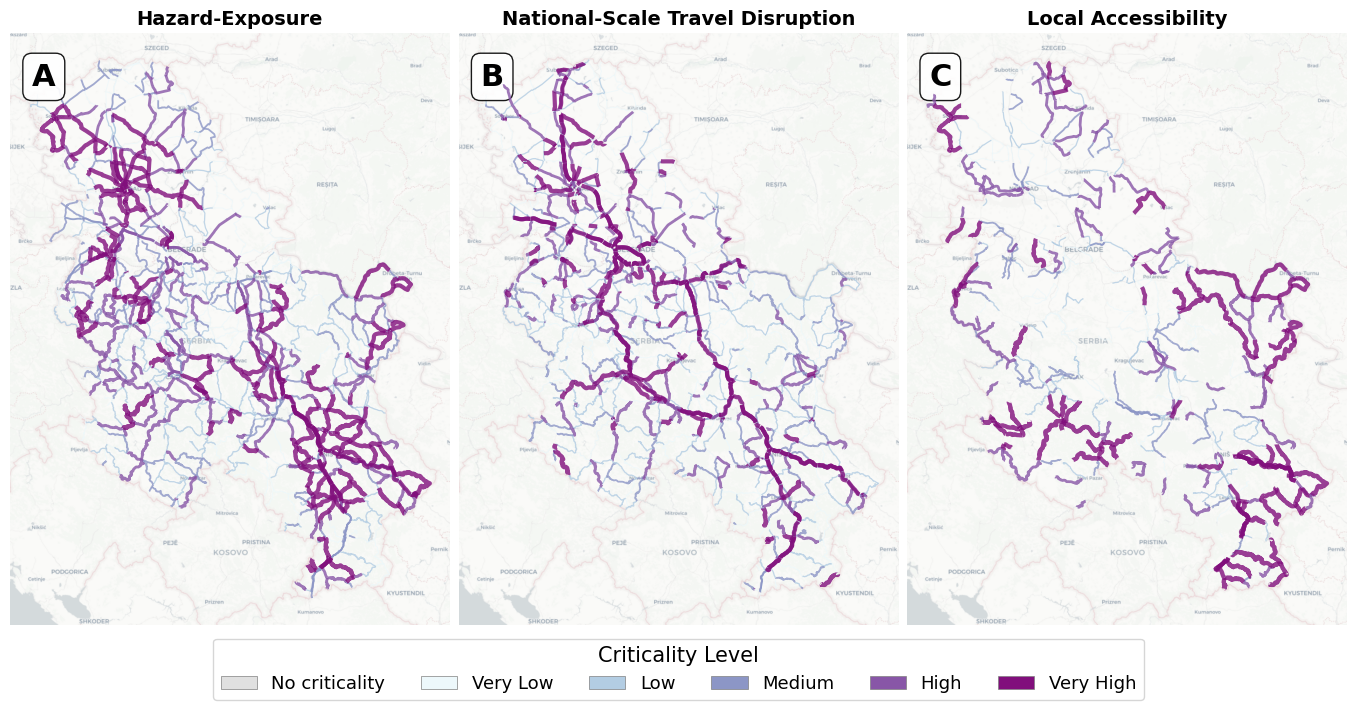

In [6]:
# 6a. Three-panel map of the H / T / A sub-indices (+ ArcGIS layers in results GDB)
plot_climate_criticality_components(
    gdf, figure_path, results_gdb, lyrx_results, show_figures=show_figures
)


Saved climate_criticality -> c:\Users\yma794\Documents\Serbia\analysis final rerun\updated input data scripts\Criticality-Analysis-Roads-Serbia\results\database\results.gdb (layer 'climate_criticality')


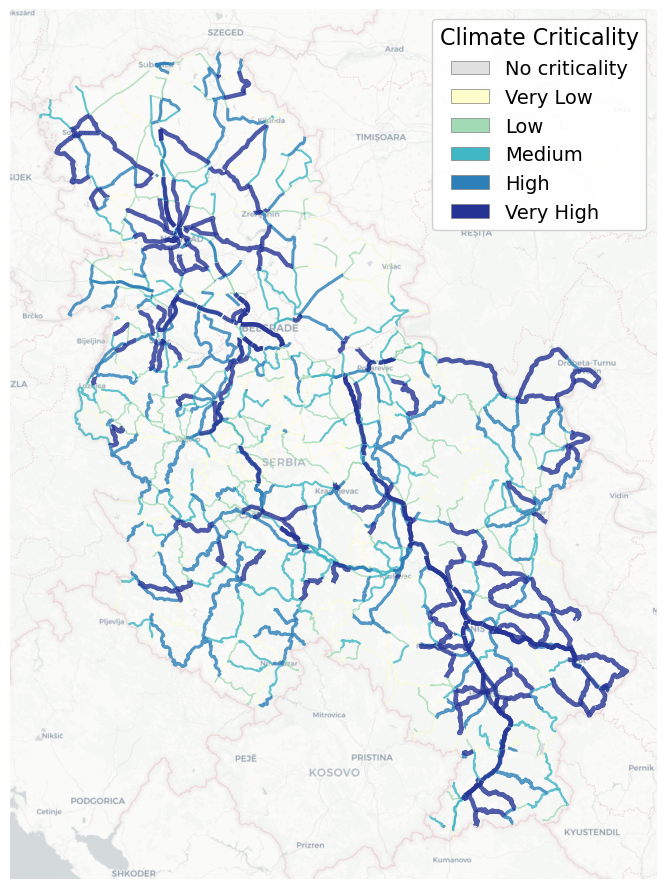

In [7]:
# 6b. Single map of the combined climate-criticality index (+ ArcGIS layer in results GDB)
plot_combined_climate_criticality(
    gdf, figure_path, results_gdb, lyrx_results, show_figures=show_figures
)


In [8]:
# Summary statistics
if print_statistics:
    print_climate_criticality_statistics(gdf)


CLIMATE CRITICALITY SUMMARY STATISTICS

1. OVERALL DISTRIBUTION BY CRITICALITY CLASS

Hazard Exposure:
  No criticality :     0 (  0.0%)
  Very Low       :   389 ( 22.3%)
  Low            :   302 ( 17.3%)
  Medium         :   358 ( 20.5%)
  High           :   333 ( 19.1%)
  Very High      :   364 ( 20.8%)

Travel Disruption:
  No criticality :    67 (  3.8%)
  Very Low       :   362 ( 20.7%)
  Low            :   340 ( 19.5%)
  Medium         :   331 ( 19.0%)
  High           :   310 ( 17.8%)
  Very High      :   336 ( 19.2%)

Local Accessibility:
  No criticality :  1014 ( 58.1%)
  Very Low       :   146 (  8.4%)
  Low            :   150 (  8.6%)
  Medium         :   134 (  7.7%)
  High           :   154 (  8.8%)
  Very High      :   148 (  8.5%)

Combined Criticality:
  No criticality :    73 (  4.2%)
  Very Low       :   339 ( 19.4%)
  Low            :   330 ( 18.9%)
  Medium         :   334 ( 19.1%)
  High           :   335 ( 19.2%)
  Very High      :   335 ( 19.2%)

2. MEAN CRITICA

In [9]:
# Formatted multi-sheet Excel workbook
export_climate_criticality_excel(
    gdf, climate_criticality_xlsx,
    climate_hazards_only=climate_hazards_only,
    normalize_subindices=normalize_subindices,
)


Saved climate-criticality workbook -> c:\Users\yma794\Documents\Serbia\analysis final rerun\updated input data scripts\Criticality-Analysis-Roads-Serbia\results\Climate_Criticality_PuteviSrbije.xlsx


In [10]:
# Geospatial export: Parquet (working CRS) + mirrored Excel
# (the reprojected geospatial copy lives as the 'climate_criticality' feature class in the results GDB)
save_climate_criticality_geospatial(gdf, parquet_path=climate_criticality_parquet)


Saved climate criticality -> c:\Users\yma794\Documents\Serbia\analysis final rerun\updated input data scripts\Criticality-Analysis-Roads-Serbia\intermediate_results\Climate_Criticality_PuteviSrbije.parquet
Saved Excel -> c:\Users\yma794\Documents\Serbia\analysis final rerun\updated input data scripts\Criticality-Analysis-Roads-Serbia\intermediate_results\excel\Climate_Criticality_PuteviSrbije.xlsx
